# Churn Modelling — Classification

Practical end-to-end workflow: EDA → Statistics → Preprocessing → ML Models → Evaluation → Tuning → Neural Network.

## 1. Setup & Data

In [43]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries loaded.")

Libraries loaded.


In [44]:
# Works when the notebook and CSV are in the same folder.
# Also supports the uploaded filename used in this environment.
possible_paths = [
    Path("Churn_Modelling.csv"),
    Path("Churn_Modelling(1).csv"),
    Path("/mnt/data/Churn_Modelling.csv"),
    Path("/mnt/data/Churn_Modelling(1).csv"),
]

csv_path = next((p for p in possible_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Churn_Modelling.csv was not found. Put it beside this notebook.")

df = pd.read_csv(csv_path)
print(f"Loaded: {csv_path}")
print(f"Shape: {df.shape}")

Loaded: Churn_Modelling.csv
Shape: (10000, 14)


In [45]:
display(df.head())
print("Shape:", df.shape)
df.info()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Shape: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [46]:
display(df.describe(include="all").T)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["Exited"].value_counts().rename_axis("Exited").to_frame("count"))

print("\nTarget proportions:")
display(df["Exited"].value_counts(normalize=True).rename_axis("Exited").to_frame("proportion"))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0



Data types:


,dtype
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64



Missing values:


,missing
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0



Duplicate rows: 0

Target distribution:


,count
Exited,
0,7963
1,2037



Target proportions:


,proportion
Exited,
0,0.7963
1,0.2037


### Initial observations

`Exited` is the binary target. The classes are imbalanced, but not extremely so (~20% churn), so we will avoid blind oversampling and evaluate with precision, recall, F1 and ROC-AUC in addition to accuracy.

## 2. Data Cleaning & EDA

In [47]:
# Remove identifiers that should not be learned as predictive features.
# Surname is also excluded because it is a high-cardinality name and is unlikely to generalize.
drop_cols = ["RowNumber", "CustomerId", "Surname"]
df_model = df.drop(columns=drop_cols).copy()

print("Removed:", drop_cols)
print("Remaining columns:", df_model.columns.tolist())

categorical_cols_all = df_model.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols_all = df_model.select_dtypes(include=np.number).columns.tolist()

print("\nCategorical:", categorical_cols_all)
print("Numerical:", numerical_cols_all)

Removed: ['RowNumber', 'CustomerId', 'Surname']
Remaining columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Categorical: ['Geography', 'Gender']
Numerical: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [48]:
print("Categorical values:")
for col in categorical_cols_all:
    print(f"\n{col}:")
    print(df_model[col].value_counts(dropna=False))

print("\nPotential numerical outliers using IQR:")
numeric_for_outliers = [c for c in numerical_cols_all if c != "Exited"]
outlier_summary = []
for col in numeric_for_outliers:
    q1, q3 = df_model[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((df_model[col] < lower) | (df_model[col] > upper)).sum()
    outlier_summary.append([col, lower, upper, count])
display(pd.DataFrame(outlier_summary, columns=["feature", "lower", "upper", "outlier_count"]))

Categorical values:

Geography:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender:
Gender
Male      5457
Female    4543
Name: count, dtype: int64

Potential numerical outliers using IQR:


,feature,lower,upper,outlier_count
0,CreditScore,383.00000,919.00000,15
1,Age,14.00000,62.00000,359
2,Tenure,-3.00000,13.00000,0
3,Balance,-191466.36000,319110.60000,0
4,NumOfProducts,-0.50000,3.50000,60
5,HasCrCard,-1.50000,2.50000,0
6,IsActiveMember,-1.50000,2.50000,0
7,EstimatedSalary,-96577.09625,296967.45375,0


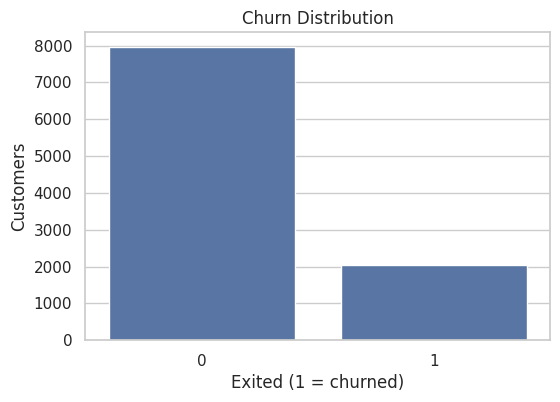

In [49]:
# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df_model, x="Exited")
plt.title("Churn Distribution")
plt.xlabel("Exited (1 = churned)")
plt.ylabel("Customers")
plt.show()

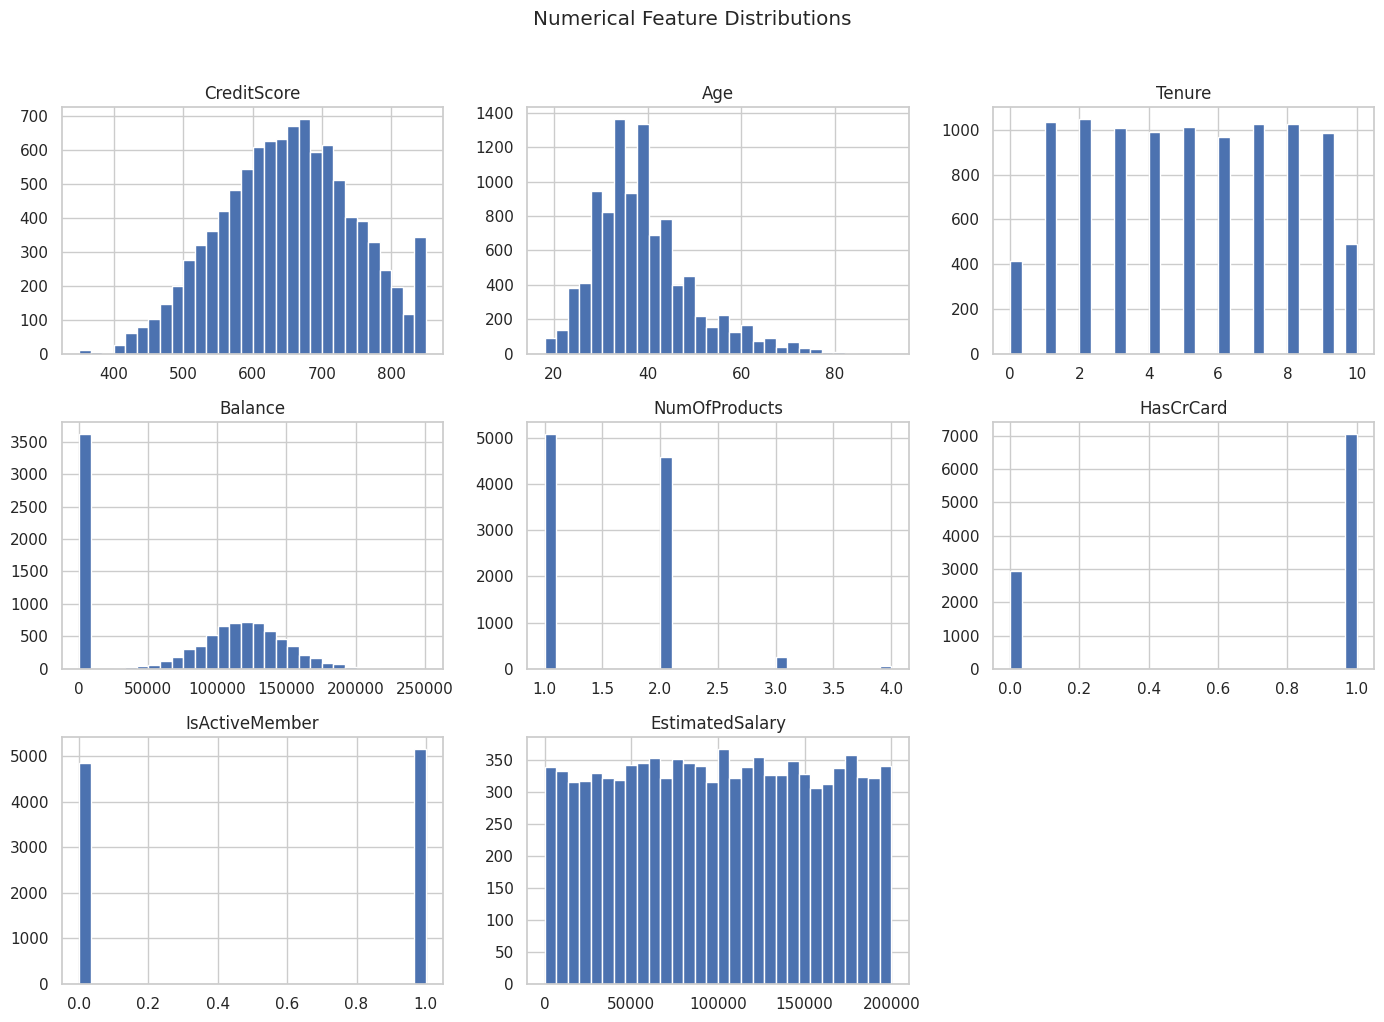

In [50]:
# Numerical distributions
df_model[numeric_for_outliers].hist(figsize=(14, 10), bins=30)
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

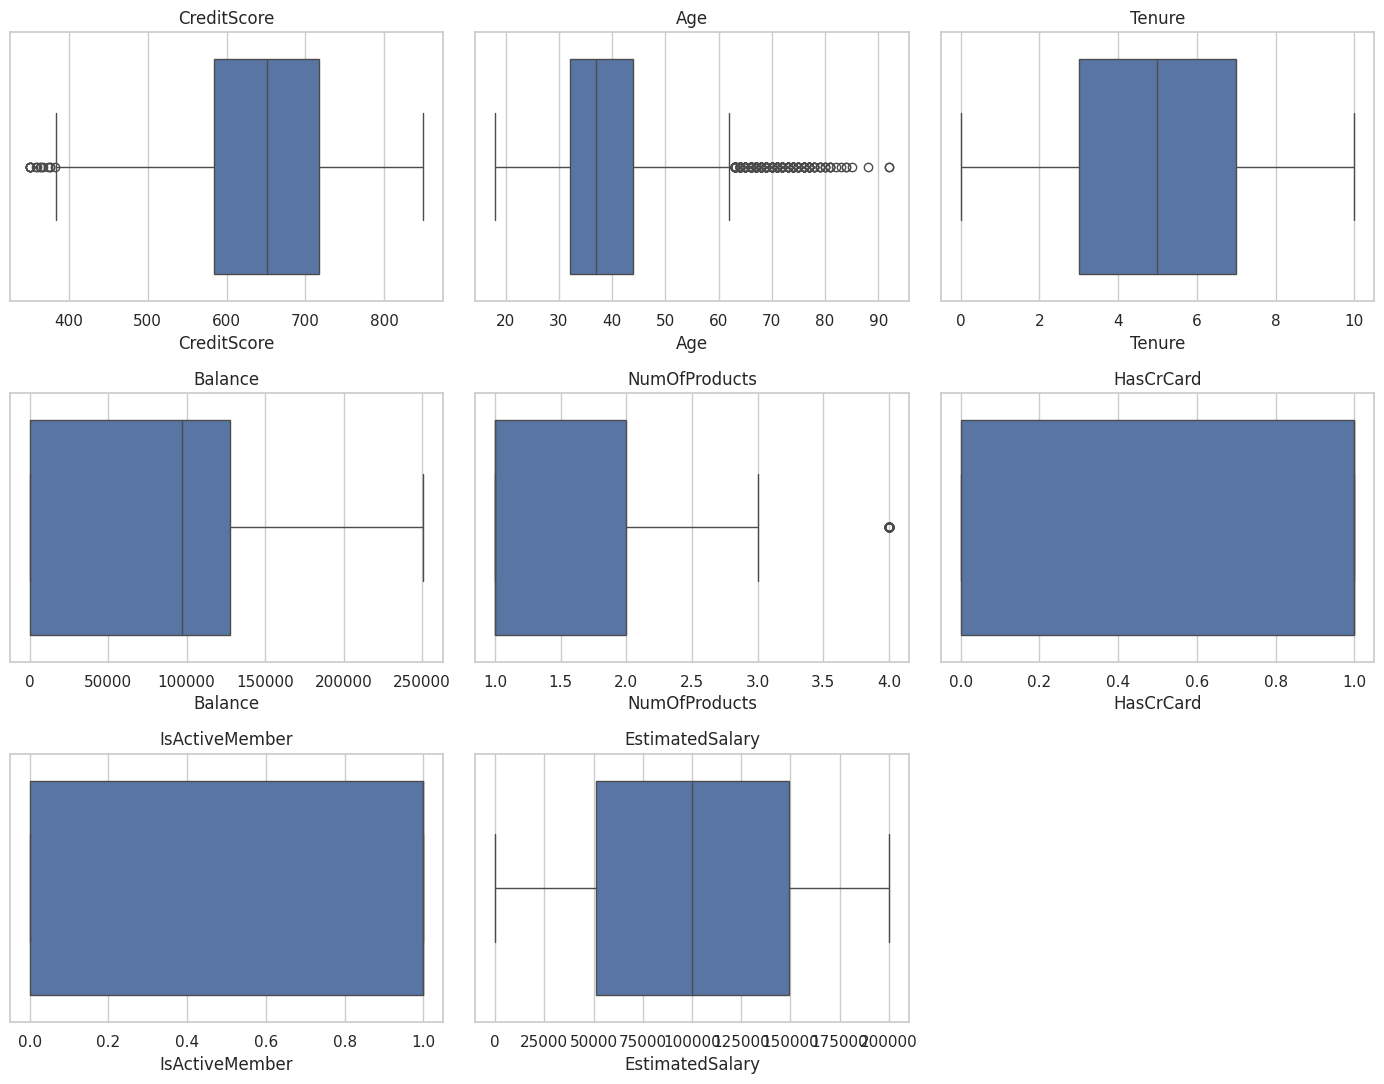

In [51]:
# Boxplots
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()
for ax, col in zip(axes, numeric_for_outliers):
    sns.boxplot(data=df_model, x=col, ax=ax)
    ax.set_title(col)
for ax in axes[len(numeric_for_outliers):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

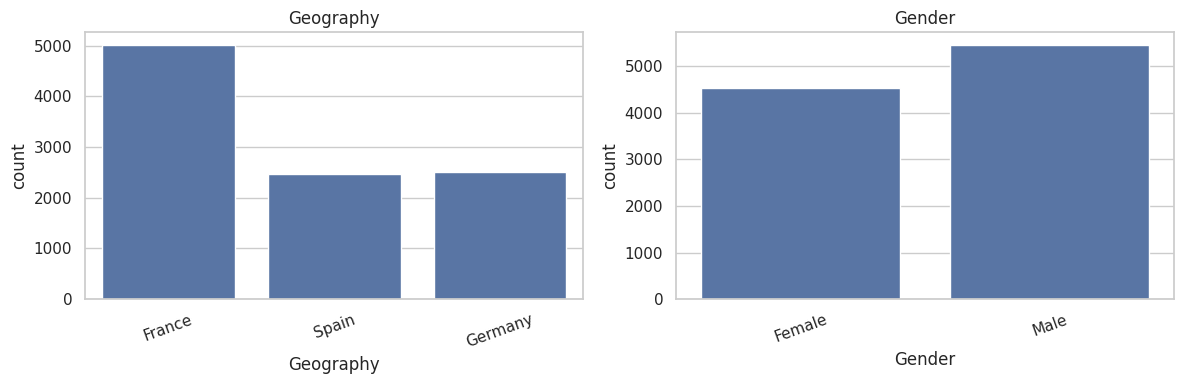

In [52]:
# Categorical distributions
fig, axes = plt.subplots(1, len(categorical_cols_all), figsize=(12, 4))
if len(categorical_cols_all) == 1:
    axes = [axes]
for ax, col in zip(axes, categorical_cols_all):
    sns.countplot(data=df_model, x=col, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

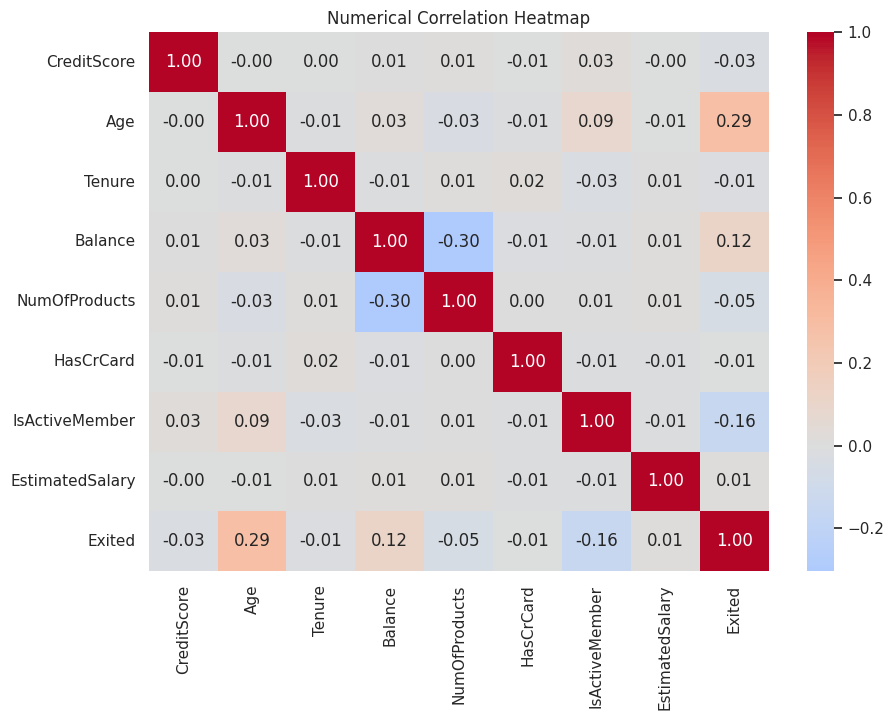

In [53]:
# Correlation heatmap for numerical variables
plt.figure(figsize=(10, 7))
corr = df_model.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numerical Correlation Heatmap")
plt.show()

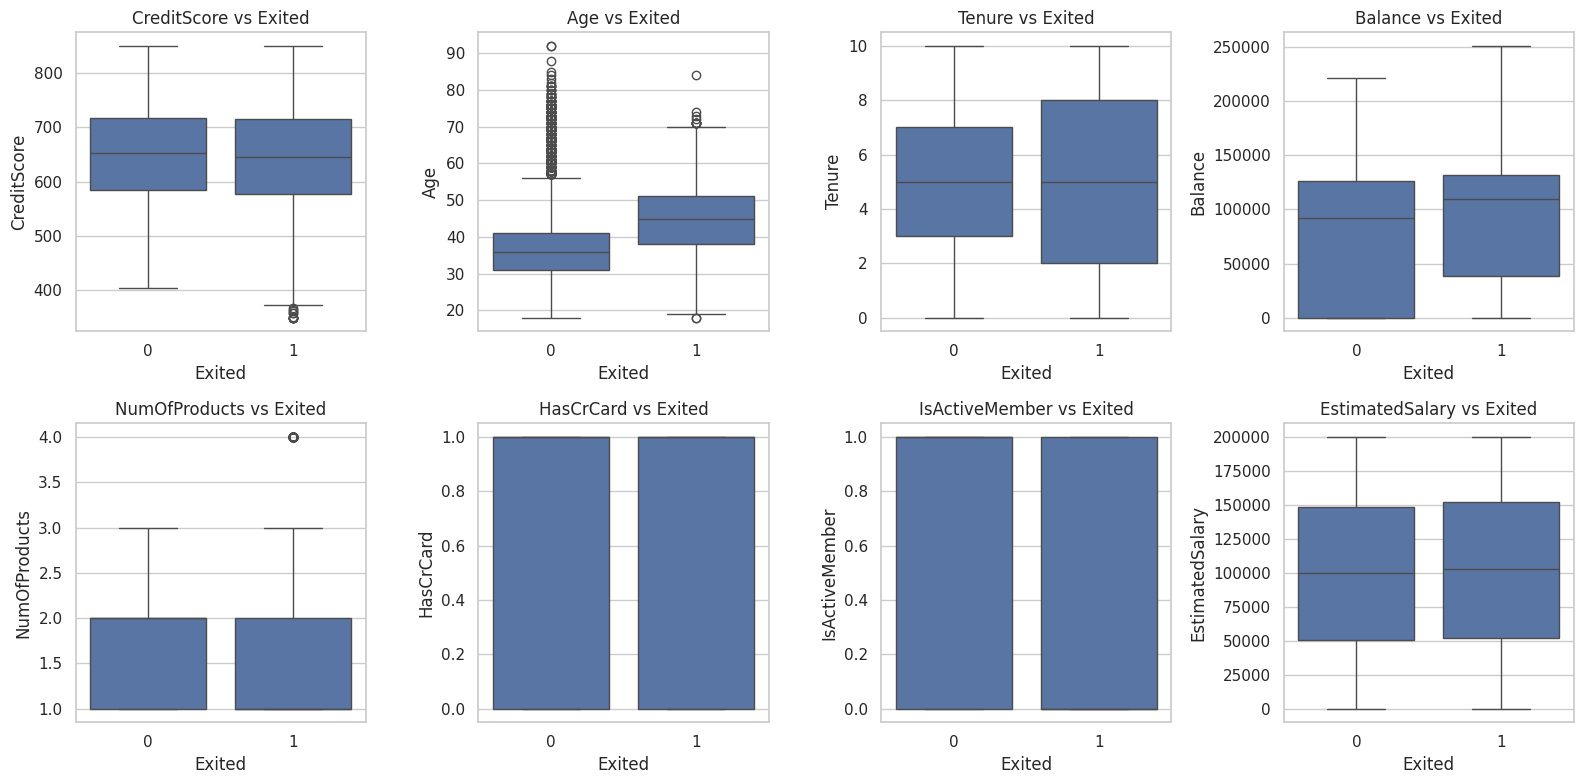

In [54]:
# Feature vs target: numeric
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, numeric_for_outliers):
    sns.boxplot(data=df_model, x="Exited", y=col, ax=ax)
    ax.set_title(f"{col} vs Exited")
for ax in axes[len(numeric_for_outliers):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

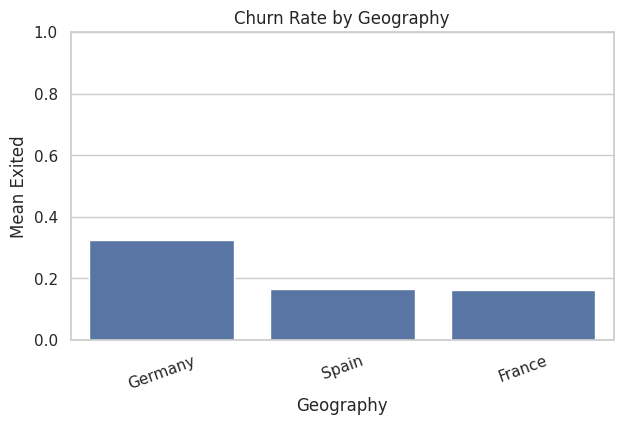

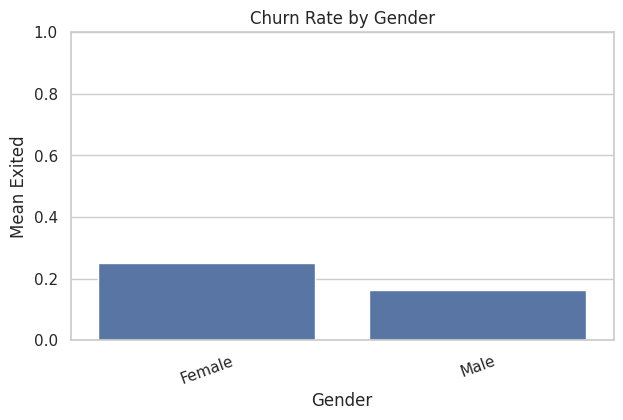

In [55]:
# Feature vs target: categorical churn rate
for col in categorical_cols_all:
    churn_rate = df_model.groupby(col, dropna=False)["Exited"].mean().sort_values(ascending=False)
    plt.figure(figsize=(7, 4))
    sns.barplot(x=churn_rate.index.astype(str), y=churn_rate.values)
    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Mean Exited")
    plt.xticks(rotation=20)
    plt.ylim(0, 1)
    plt.show()

### EDA findings

- `Geography` and `Gender` are categorical and need encoding.
- `Age`, `Balance`, `CreditScore`, `NumOfProducts`, and activity-related variables can show useful differences between churned and retained customers.
- Some numerical variables have outliers; tree models are generally robust to them, while scaling helps Logistic Regression and the neural network.
- `Surname`, `RowNumber`, and `CustomerId` are excluded to improve generalization and avoid learning identifiers.

## 3. Statistics & ML Concepts

In [56]:
stats_cols = ["CreditScore", "Age", "Balance", "EstimatedSalary"]

stats_table = pd.DataFrame({
    "mean": df_model[stats_cols].mean(),
    "median": df_model[stats_cols].median(),
    "variance": df_model[stats_cols].var(),
    "std": df_model[stats_cols].std()
})
display(stats_table)

,mean,median,variance,std
CreditScore,650.528800,652.000,9.341860e+03,96.653299
Age,38.921800,37.000,1.099941e+02,10.487806
Balance,76485.889288,97198.540,3.893436e+09,62397.405202
EstimatedSalary,100090.239881,100193.915,3.307457e+09,57510.492818


In [57]:
print("Correlation with Exited:")
display(df_model.select_dtypes(include=np.number).corr()["Exited"].sort_values(ascending=False).to_frame("correlation"))

print("\nCovariance with Exited:")
display(df_model.select_dtypes(include=np.number).cov()["Exited"].sort_values(ascending=False).to_frame("covariance"))

Correlation with Exited:


,correlation
Exited,1.000000
Age,0.285323
Balance,0.118533
EstimatedSalary,0.012097
HasCrCard,-0.007138
Tenure,-0.014001
CreditScore,-0.027094
NumOfProducts,-0.047820
IsActiveMember,-0.156128



Covariance with Exited:


,covariance
Balance,2978.931708
EstimatedSalary,280.204670
Age,1.205250
Exited,0.162223
HasCrCard,-0.001310
NumOfProducts,-0.011203
Tenure,-0.016309
IsActiveMember,-0.031429
CreditScore,-1.054722


In [58]:
# Probability / class distribution
class_probability = df_model["Exited"].value_counts(normalize=True).sort_index()
display(class_probability.rename("P(Exited)").to_frame())

,P(Exited)
Exited,
0,0.7963
1,0.2037


In [59]:
# Feature matrix X and target y
X_demo = df_model.drop(columns="Exited")
y_demo = df_model["Exited"]

print("X shape:", X_demo.shape)
print("y shape:", y_demo.shape)
print("One row of X:")
display(X_demo.head(1))
print("One value of y:", y_demo.iloc[0])

X shape: (10000, 10)
y shape: (10000,)
One row of X:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.0,1,1,1,101348.88


One value of y: 1


In [60]:
# Simple vector/matrix idea:
# X is a matrix of observations/features, w is a vector of weights, and b is a bias.
X_small = np.array([[1.0, 2.0], [2.0, 1.0], [3.0, 4.0]])
w = np.array([0.5, -0.2])
b = 0.1
y_linear = X_small @ w + b

print("X shape:", X_small.shape)
print("w shape:", w.shape)
print("y = Xw + b:", y_linear)

X shape: (3, 2)
w shape: (2,)
y = Xw + b: [0.2 0.9 0.8]


Optimized w: 2.9963


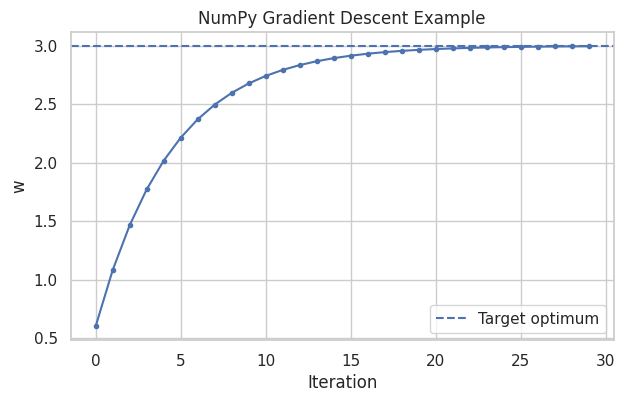

In [61]:
# Tiny NumPy gradient-descent example: minimize f(w) = (w - 3)^2
w = 0.0
learning_rate = 0.1
history = []

for _ in range(30):
    gradient = 2 * (w - 3)
    w -= learning_rate * gradient
    history.append(w)

print("Optimized w:", round(w, 4))

plt.figure(figsize=(7, 4))
plt.plot(history, marker="o", markersize=3)
plt.axhline(3, linestyle="--", label="Target optimum")
plt.title("NumPy Gradient Descent Example")
plt.xlabel("Iteration")
plt.ylabel("w")
plt.legend()
plt.show()

**Idea:** gradient descent repeatedly changes model parameters in the direction that reduces the loss.

## 4. Preprocessing

In [62]:
X = df_model.drop(columns="Exited")
y = df_model["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Train: (8000, 10) (8000,)
Test : (2000, 10) (2000,)
Numeric features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Categorical features: ['Geography', 'Gender']


The preprocessing is fitted only on training data through the sklearn `Pipeline`, which prevents data leakage.

## 5. Machine Learning Models

In [63]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=6),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    )
}

pipelines = {
    name: Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

In [64]:
def evaluate_model(name, fitted_model, X_eval, y_eval):
    y_pred = fitted_model.predict(X_eval)
    y_prob = fitted_model.predict_proba(X_eval)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1": f1_score(y_eval, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, y_prob)
    }

results = []
fitted_models = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    results.append(evaluate_model(name, pipe, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.8580,0.7595,0.4423,0.5590,0.8491
1,Decision Tree,0.8605,0.7759,0.4423,0.5634,0.8402
2,Logistic Regression,0.8080,0.5891,0.1867,0.2836,0.7748


In [65]:
# Detailed evaluation for each model
for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    print("=" * 70)
    print(name)
    print(classification_report(y_test, y_pred, digits=4))

Logistic Regression
              precision    recall  f1-score   support

           0     0.8231    0.9667    0.8891      1593
           1     0.5891    0.1867    0.2836       407

    accuracy                         0.8080      2000
   macro avg     0.7061    0.5767    0.5864      2000
weighted avg     0.7755    0.8080    0.7659      2000

Decision Tree
              precision    recall  f1-score   support

           0     0.8716    0.9674    0.9170      1593
           1     0.7759    0.4423    0.5634       407

    accuracy                         0.8605      2000
   macro avg     0.8237    0.7048    0.7402      2000
weighted avg     0.8521    0.8605    0.8450      2000

Random Forest
              precision    recall  f1-score   support

           0     0.8712    0.9642    0.9154      1593
           1     0.7595    0.4423    0.5590       407

    accuracy                         0.8580      2000
   macro avg     0.8154    0.7032    0.7372      2000
weighted avg     0.8485   

## 6. Evaluation

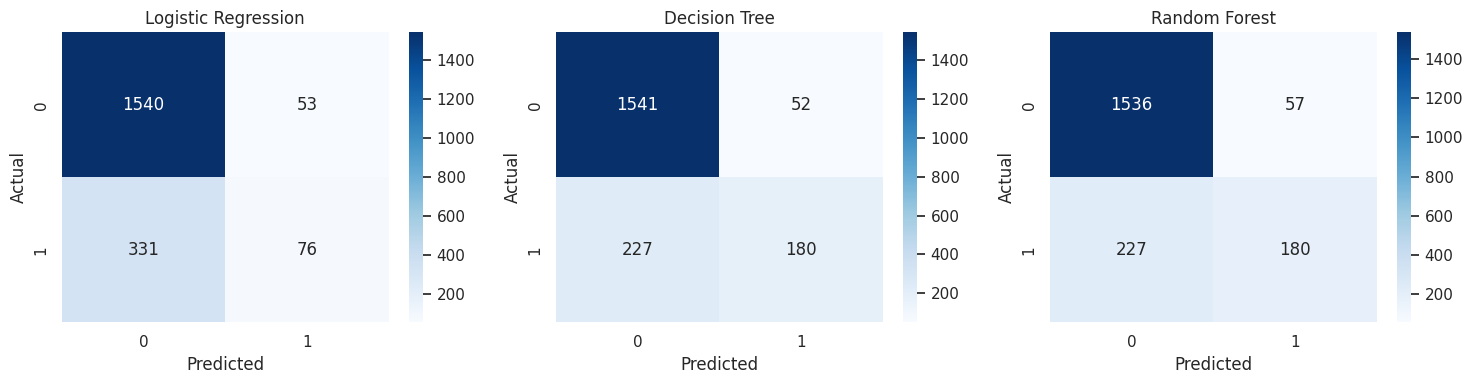

In [66]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, fitted_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

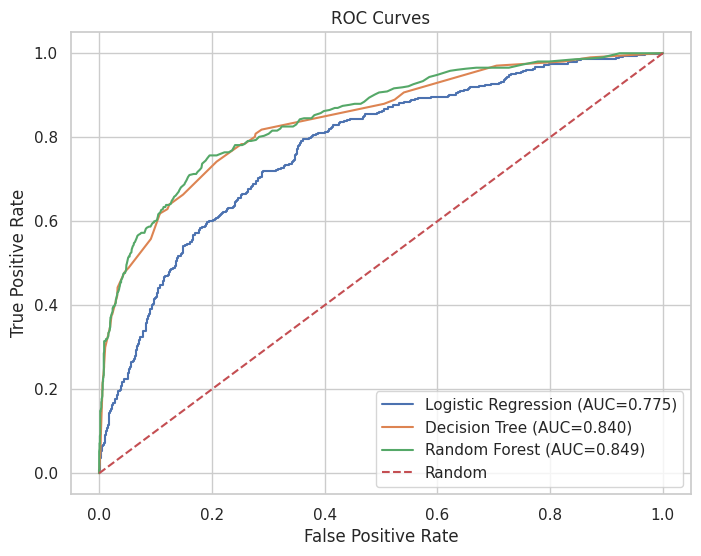

In [67]:
# ROC curves
plt.figure(figsize=(8, 6))
for name, model in fitted_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [68]:
# Train vs test performance
train_test_rows = []
for name, model in fitted_models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    train_test_rows.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train F1": f1_score(y_train, train_pred, zero_division=0),
        "Test F1": f1_score(y_test, test_pred, zero_division=0),
        "Train ROC-AUC": roc_auc_score(y_train, train_prob),
        "Test ROC-AUC": roc_auc_score(y_test, test_prob),
    })

train_test_df = pd.DataFrame(train_test_rows)
display(train_test_df.round(4))

,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression,0.8108,0.8080,0.3168,0.2836,0.7654,0.7748
1,Decision Tree,0.8681,0.8605,0.5868,0.5634,0.8628,0.8402
2,Random Forest,1.0000,0.8580,1.0000,0.5590,1.0000,0.8491


### Evaluation notes

A large train score with a much lower test score suggests overfitting. A low score on both suggests underfitting. Because churn is the positive class, recall and F1 are especially useful when missing churners is costly.

## 7. Model Improvement

In [69]:
# Use cross-validation on the training set to choose the best traditional model.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = []
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_scores.append({
        "Model": name,
        "CV ROC-AUC Mean": scores.mean(),
        "CV ROC-AUC Std": scores.std()
    })

cv_df = pd.DataFrame(cv_scores).sort_values("CV ROC-AUC Mean", ascending=False).reset_index(drop=True)
display(cv_df.round(4))

best_traditional_name = cv_df.iloc[0]["Model"]
print("Best traditional model by CV ROC-AUC:", best_traditional_name)

,Model,CV ROC-AUC Mean,CV ROC-AUC Std
0,Random Forest,0.8497,0.0138
1,Decision Tree,0.8263,0.0146
2,Logistic Regression,0.7628,0.0199


Best traditional model by CV ROC-AUC: Random Forest


In [28]:
# Reasonable hyperparameter grids for each possible best traditional model.
param_grids = {
    "Logistic Regression": {
        "model__C": [0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    },
    "Decision Tree": {
        "model__max_depth": [3, 5, 7, 10, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 5],
        "model__class_weight": [None, "balanced"]
    },
    "Random Forest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 8, 12],
        "model__min_samples_leaf": [1, 2, 5],
        "model__max_features": ["sqrt", "log2"],
        "model__class_weight": [None, "balanced"]
    }
}

best_pipe = pipelines[best_traditional_name]

grid_search = GridSearchCV(
    estimator=best_pipe,
    param_grid=param_grids[best_traditional_name],
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)
tuned_model = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 4))

Best parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 400}
Best CV ROC-AUC: 0.8577


In [29]:
tuned_result = evaluate_model(
    f"Tuned {best_traditional_name}",
    tuned_model,
    X_test,
    y_test
)

before = results_df.loc[results_df["Model"] == best_traditional_name].iloc[0].to_dict()
after = tuned_result

improvement = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Before": [before["Accuracy"], before["Precision"], before["Recall"], before["F1"], before["ROC-AUC"]],
    "After": [after["Accuracy"], after["Precision"], after["Recall"], after["F1"], after["ROC-AUC"]]
})
improvement["Change"] = improvement["After"] - improvement["Before"]

display(improvement.round(4))

,Metric,Before,After,Change
0,Accuracy,0.8580,0.8195,-0.0385
1,Precision,0.7595,0.5431,-0.2164
2,Recall,0.4423,0.7125,0.2703
3,F1,0.5590,0.6164,0.0574
4,ROC-AUC,0.8491,0.8615,0.0124


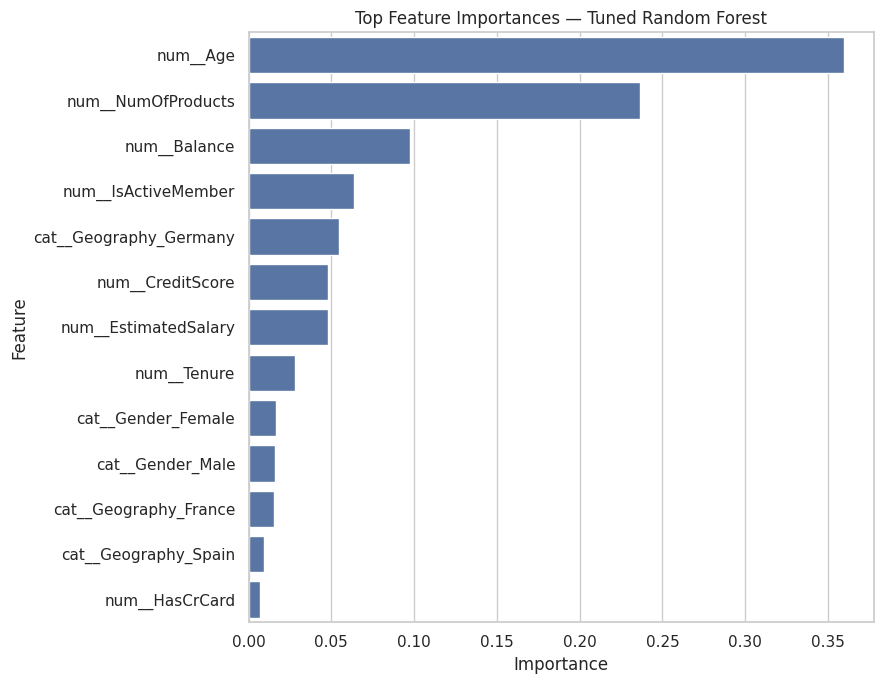

,Feature,Importance
1,num__Age,0.359833
4,num__NumOfProducts,0.236439
3,num__Balance,0.097793
6,num__IsActiveMember,0.064021
9,cat__Geography_Germany,0.054582
0,num__CreditScore,0.047946
7,num__EstimatedSalary,0.047741
2,num__Tenure,0.027823
11,cat__Gender_Female,0.016398
12,cat__Gender_Male,0.015741


In [30]:
# Feature importance for the tuned tree-based model.
if best_traditional_name in ["Decision Tree", "Random Forest"]:
    fitted_preprocessor = tuned_model.named_steps["preprocessor"]
    tree_model = tuned_model.named_steps["model"]
    feature_names = fitted_preprocessor.get_feature_names_out()

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": tree_model.feature_importances_
    }).sort_values("Importance", ascending=False).head(20)

    plt.figure(figsize=(9, 7))
    sns.barplot(data=importance_df, x="Importance", y="Feature")
    plt.title(f"Top Feature Importances — Tuned {best_traditional_name}")
    plt.tight_layout()
    plt.show()

    display(importance_df)
else:
    print("Feature importance plot is skipped because the selected model is not tree-based.")

In [31]:
# Save the tuned traditional model.
joblib.dump(tuned_model, "churn_tuned_traditional_model.joblib")
print("Saved: churn_tuned_traditional_model.joblib")

Saved: churn_tuned_traditional_model.joblib


Tuning searches for parameters that improve cross-validated ROC-AUC on the training data. The untouched test set is used only for final evaluation.

## 8. Neural Network / Deep Learning

In [32]:
# TensorFlow/Keras setup.
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ImportError:
    print("TensorFlow is not installed. Installing it now...")
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow", "-q"])
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

tf.keras.utils.set_random_seed(RANDOM_STATE)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [33]:
# Transform data for Keras using the same leakage-safe preprocessing.
nn_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features)
])

X_train_nn = nn_preprocessor.fit_transform(X_train).astype("float32")
X_test_nn = nn_preprocessor.transform(X_test).astype("float32")

print("Neural-network input shape:", X_train_nn.shape)

Neural-network input shape: (8000, 13)


In [34]:
nn_model = keras.Sequential([
    keras.Input(shape=(X_train_nn.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train_nn, y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8014 - auc: 0.7174 - loss: 0.4582 - val_accuracy: 0.8313 - val_auc: 0.7784 - val_loss: 0.4132
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8306 - auc: 0.8025 - loss: 0.4015 - val_accuracy: 0.8494 - val_auc: 0.8145 - val_loss: 0.3830
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8447 - auc: 0.8283 - loss: 0.3779 - val_accuracy: 0.8544 - val_auc: 0.8388 - val_loss: 0.3606
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8506 - auc: 0.8435 - loss: 0.3615 - val_accuracy: 0.8619 - val_auc: 0.8510 - val_loss: 0.3470
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8556 - auc: 0.8524 - loss: 0.3512 - val_accuracy: 0.8656 - val_auc: 0.8563 - val_loss: 0.3401
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8592 - auc: 0.8574 - loss: 0.3451 - val_accuracy: 0.8675 - val_auc: 0.8589 - val_loss: 0.3363
Epoch 7/100
200/200 ━━━━━━━━━━━━━━

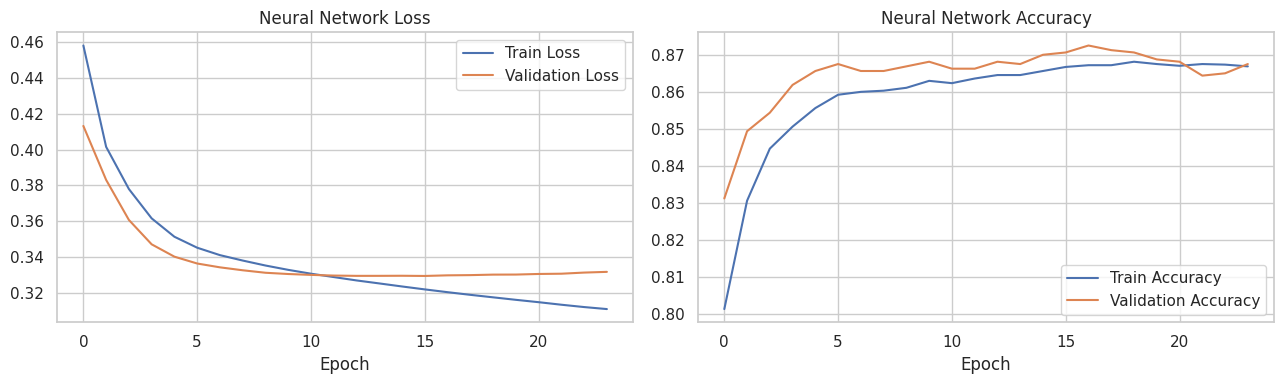

In [35]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].set_title("Neural Network Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[1].set_title("Neural Network Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [36]:
nn_prob = nn_model.predict(X_test_nn, verbose=0).ravel()
nn_pred = (nn_prob >= 0.5).astype(int)

nn_result = {
    "Model": "Neural Network",
    "Accuracy": accuracy_score(y_test, nn_pred),
    "Precision": precision_score(y_test, nn_pred, zero_division=0),
    "Recall": recall_score(y_test, nn_pred, zero_division=0),
    "F1": f1_score(y_test, nn_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, nn_prob)
}

print(classification_report(y_test, nn_pred, digits=4))
display(pd.DataFrame([nn_result]).round(4))

              precision    recall  f1-score   support

           0     0.8746    0.9630    0.9166      1593
           1     0.7602    0.4595    0.5727       407

    accuracy                         0.8605      2000
   macro avg     0.8174    0.7112    0.7447      2000
weighted avg     0.8513    0.8605    0.8467      2000



,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Neural Network,0.8605,0.7602,0.4595,0.5727,0.8581


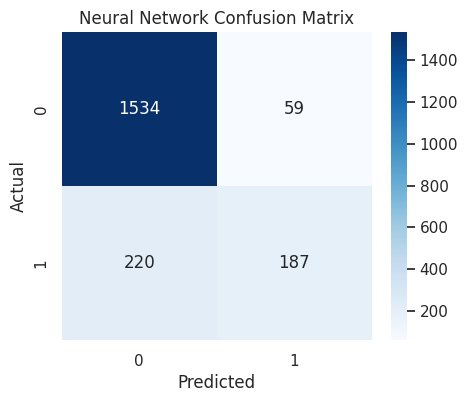

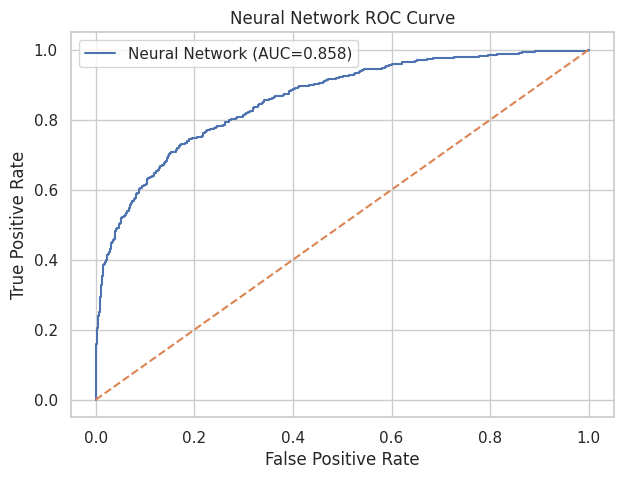

In [37]:
# Neural network confusion matrix and ROC curve
cm = confusion_matrix(y_test, nn_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr_nn, tpr_nn, label=f"Neural Network (AUC={nn_result['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Neural Network ROC Curve")
plt.legend()
plt.show()

In [38]:
# Save the trained neural network and its preprocessing object.
nn_model.save("churn_neural_network.keras")
joblib.dump(nn_preprocessor, "churn_neural_network_preprocessor.joblib")
print("Saved neural network artifacts.")

Saved neural network artifacts.


## 9. Final Comparison

In [39]:
# Build final comparison table.
base_final = results_df[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].copy()

tuned_name = f"Tuned {best_traditional_name}"
tuned_row = pd.DataFrame([tuned_result])[base_final.columns]
nn_row = pd.DataFrame([nn_result])[base_final.columns]

final_comparison = pd.concat([base_final, tuned_row, nn_row], ignore_index=True)
final_comparison = final_comparison.drop_duplicates(subset=["Model"], keep="last")
final_comparison = final_comparison.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

display(final_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Tuned Random Forest,0.8195,0.5431,0.7125,0.6164,0.8615
1,Neural Network,0.8605,0.7602,0.4595,0.5727,0.8581
2,Random Forest,0.8580,0.7595,0.4423,0.5590,0.8491
3,Decision Tree,0.8605,0.7759,0.4423,0.5634,0.8402
4,Logistic Regression,0.8080,0.5891,0.1867,0.2836,0.7748


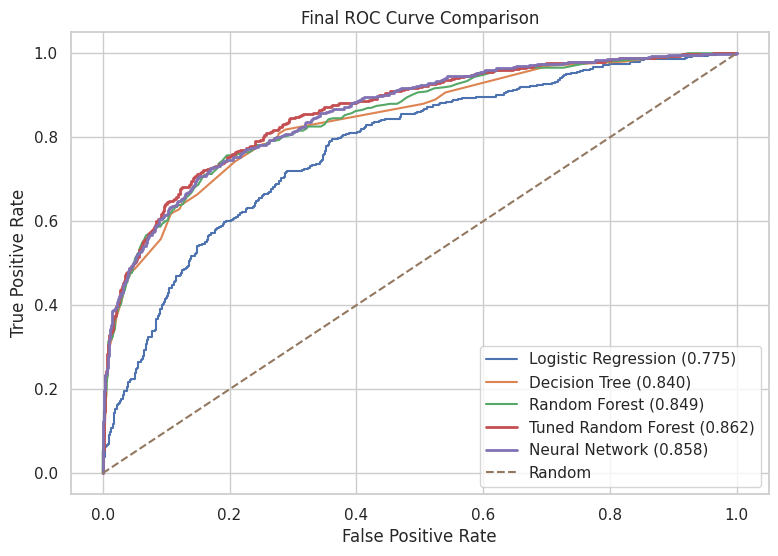

In [40]:
# Final ROC comparison
plt.figure(figsize=(9, 6))

for name, model in fitted_models.items():
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} ({roc_auc_score(y_test, prob):.3f})")

tuned_prob = tuned_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, tuned_prob)
plt.plot(fpr, tpr, linewidth=2, label=f"{tuned_name} ({roc_auc_score(y_test, tuned_prob):.3f})")

plt.plot(fpr_nn, tpr_nn, linewidth=2, label=f"Neural Network ({nn_result['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Curve Comparison")
plt.legend()
plt.show()

In [41]:
# Select the final best model by test ROC-AUC.
best_final_row = final_comparison.iloc[0]
best_final_name = best_final_row["Model"]

print("Best model:", best_final_name)
print("Reason: it has the highest ROC-AUC on the held-out test set.")
print("\nFinal metrics:")
display(best_final_row.to_frame("value"))

Best model: Tuned Random Forest
Reason: it has the highest ROC-AUC on the held-out test set.

Final metrics:


,value
Model,Tuned Random Forest
Accuracy,0.8195
Precision,0.543071
Recall,0.712531
F1,0.616366
ROC-AUC,0.861502


In [42]:
# Save the final best model artifact.
if best_final_name == "Neural Network":
    nn_model.save("best_churn_model.keras")
    joblib.dump(nn_preprocessor, "best_churn_preprocessor.joblib")
    print("Saved: best_churn_model.keras")
    print("Saved: best_churn_preprocessor.joblib")
else:
    joblib.dump(tuned_model if best_final_name == tuned_name else fitted_models[best_final_name],
                "best_churn_model.joblib")
    print("Saved: best_churn_model.joblib")

Saved: best_churn_model.joblib


## Conclusion

The notebook compared classical ML and a neural network using the same held-out test set and multiple classification metrics.

For churn prediction, do not judge the model by accuracy alone. Compare **precision, recall, F1, and ROC-AUC**, then consider the business cost of false negatives (missed churners) versus false positives.